# NLP Project 2
**ESILV A4 DIA6 — 2026**

**Authors:** Leo WINTER & Alvaro SERERO

## Table of Contents
1. [Setup & Imports](#setup)
3. [Load & Merge Data](#load)
4. [Exploratory Data Analysis](#eda)
   - 4.1 [Rating Distribution](#rating)
   - 4.2 [Reviews per Insurer](#insurer)
   - 4.3 [Reviews per Product Type](#product)
   - 4.4 [Average Rating per Insurer](#avg_rating)
5. [Frequent Words & N-grams](#ngrams)
6. [Data Cleaning](#cleaning)
7. [Visualization](#visualization)
8.
8. [Conclusion](#conclusion)

📋 Project Roadmap (in recommended order)
- Step 1 — Data Cleaning & EDA
-       Load all 35 files, merge, visualize distributions, find frequent words/n-grams, and do spelling correction to fill avis_cor
- Step 2 — Summary, Translation & Generation
-       Use a model (e.g. HuggingFace) to produce clean summaries and populate avis_cor_en
- Step 3 — Topic Modeling
-       LDA or BERTopic to find themes in reviews (pricing, service, claims, etc.)
- Step 4 — Embeddings
-       Train Word2Vec, use GloVe, visualize with Matplotlib/TensorBoard, implement semantic search
- Step 5 — Supervised Learning (star rating prediction)
-       TF-IDF + classical ML → Basic embedding model → Pre-trained embeddings → BERT/USE/LLM
- Step 6 — Streamlit Apps
-       Prediction app + Insurer analysis dashboard

In [3]:
#TODO:
# - Afficher le nombre de fichiers excel dans le dossier data
# - Afficher le nombre de lignes et de colonnes de chaque dataset
# - Afficher la shape, data types, nombre de valeurs uniques, de valeurs manquantes de chaque dataset, nombre de dupliqués

## 0. Dependencies

In [6]:
# !pip install pandas openpyxl matplotlib seaborn wordcloud textblob deep-translator tqdm nlpclean

## 1. Setup & Imports

In [ ]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src import preprocessing as ppr
import re
from collections import Counter
from nltk.corpus import stopwords
from spellchecker import SpellChecker

# Ensure the visualizations directory exists
Path("visualizations").mkdir(exist_ok=True)


# Downloading model for cleaning the text
nltk.download('stopwords')
STOP_WORDS_FR = set(stopwords.words('french'))
STOP_WORDS_EN = set(stopwords.words('english'))
MODEL_CORRECTION_FR = SpellChecker(language='fr')
MODEL_CORRECTION_EN = SpellChecker(language='en')

## 2. Load & Merge Data

The dataset consists of 35 Excel files, each containing reviews for an insurance product. We will load all these files, merge them into a single DataFrame, and perform an initial exploration to understand the structure and content of the data.

The dataset contains the following columns:

| Column | Description                                         |
| :--- |:----------------------------------------------------|
| `note` | Star rating 1–5 (main prediction target)            |
| `avis` | Original review in French                           |
| `avis_en` | Automatic translation of the review to English      |
| `avis_cor` | Corrected French review                             |
| `avis_cor_en` | Corrected and translated English review             |
| `assureur` | Insurance company name                              |
| `produit` | Insurance product type (auto, santé, animaux, etc.) |
| `date_publication` | Review date                                         |

In [2]:
CURRENT_DIR = Path.cwd()
DATA_PATH = CURRENT_DIR / "data"

def read_dataset(n:int=35) -> list[pd.DataFrame]:
    dataset_list = []
    for i in range(1, n + 1):
        try:
            file_name = f"avis_{i}_traduit.xlsx"
            dataset_list.append(pd.read_excel(DATA_PATH / file_name, engine="openpyxl"))
        except Exception as e:
            print(f"Error when reading the {file_name} ->{e}")
    return dataset_list

def fusion_dataset(dataset_list: list[pd.DataFrame])-> pd.DataFrame:
    try:
        df_final = pd.concat(dataset_list, ignore_index=True)
        return df_final
    except Exception as e:
        print(f"Error  : {e}")
        return pd.DataFrame()

With pandas, we need to have openpyxl installed to read an .xlsx file

In [3]:
dataset_list= read_dataset()
print(f"Found {len(dataset_list)} Excel files")

Found 35 Excel files


In [4]:
df = fusion_dataset(dataset_list)
df.head(5)

,note,auteur,avis,assureur,produit,type,date_publication,date_exp,avis_en,avis_cor,avis_cor_en
0,5.0,brahim--k-131532,"Meilleurs assurances, prix, solutions, écoute,...",Direct Assurance,auto,train,06/09/2021,01/09/2021,"Best insurance, price, solutions, listening, s...",NaN,NaN
1,4.0,bernard-g-112497,"je suis globalement satisfait , sauf que vous ...",Direct Assurance,auto,train,03/05/2021,01/05/2021,"I am generally satisfied, except that you have...",NaN,NaN
2,5.0,virginie-t-107352,Prix tres abordable plusieurs options s'offren...,Direct Assurance,auto,train,21/03/2021,01/03/2021,Very affordable price Several options are avai...,NaN,NaN
3,4.0,boulain-f-116580,"je satisfait du service, une réponse très rapi...",L'olivier Assurance,auto,train,10/06/2021,01/06/2021,"I satisfy the service, a very fast response fr...",NaN,NaN
4,1.0,ouaille31-51798,"Client depuis plus de 25 ans, très déçu de cet...",Matmut,auto,train,29/01/2017,01/01/2017,"Customer for more than 25 years, very disappoi...",NaN,NaN


In [24]:
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Shape: (34435, 11)

Dtypes:
 note                float64
auteur               object
avis                 object
assureur             object
produit              object
type                 object
date_publication     object
date_exp             object
avis_en              object
avis_cor             object
avis_cor_en          object
dtype: object

Missing values:
 note                10331
auteur                  1
avis                    0
assureur                0
produit                 0
type                    0
date_publication        0
date_exp                0
avis_en                 2
avis_cor            34000
avis_cor_en         34004
dtype: int64

Duplicate rows: 5


In [40]:
display(df.describe(include='all').loc[['count', 'unique',]].T)

,count,unique
note,24104.0,NaN
auteur,34434,33569
avis,34435,34377
assureur,34435,56
produit,34435,13
type,34435,2
date_publication,34435,1815
date_exp,34435,61
avis_en,34433,33264
avis_cor,435,435


## 3. Exploratory Data Analysis

### 3.1 Rating Distribution

In [ ]:
note_counts = df["note"].value_counts().sort_index()
note_counts

note
1.0    7271
2.0    3716
3.0    3382
4.0    4885
5.0    4850
Name: count, dtype: int64

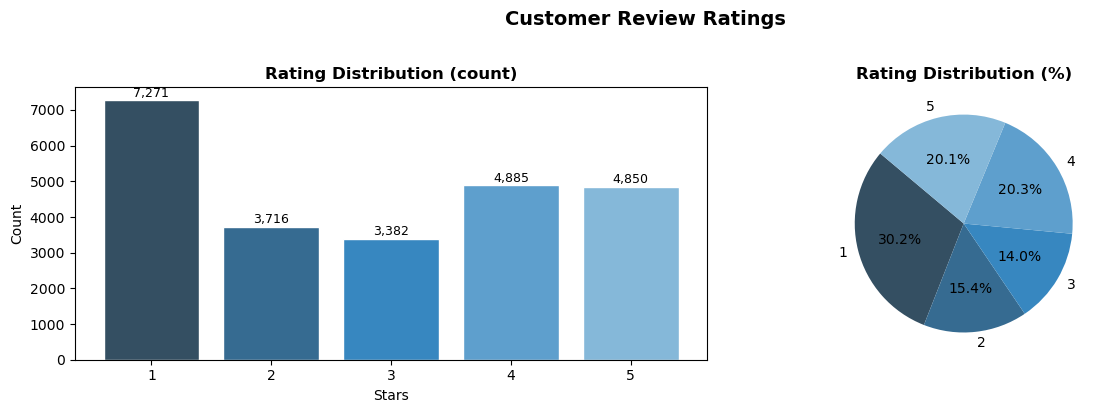

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Count plot
bars = axes[0].bar(note_counts.index, note_counts.values,
                   color=sns.color_palette("Blues_d", 5)[::-1], edgecolor="white")
axes[0].set_title("Rating Distribution (count)", fontweight="bold")
axes[0].set_xlabel("Stars"); axes[0].set_ylabel("Count")
for bar in bars:
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 20, f"{bar.get_height():,}",
                 ha="center", va="bottom", fontsize=9)

# Pie chart
axes[1].pie(note_counts.values, labels=[f"{int(i)}" for i in note_counts.index],
            autopct="%1.1f%%", startangle=140,
            colors=sns.color_palette("Blues_d", 5)[::-1])
axes[1].set_title("Rating Distribution (%)", fontweight="bold")

plt.suptitle("Customer Review Ratings", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("visualizations/rating_distribution.png", bbox_inches="tight")
plt.show()

### 3.2 Reviews per Insurer

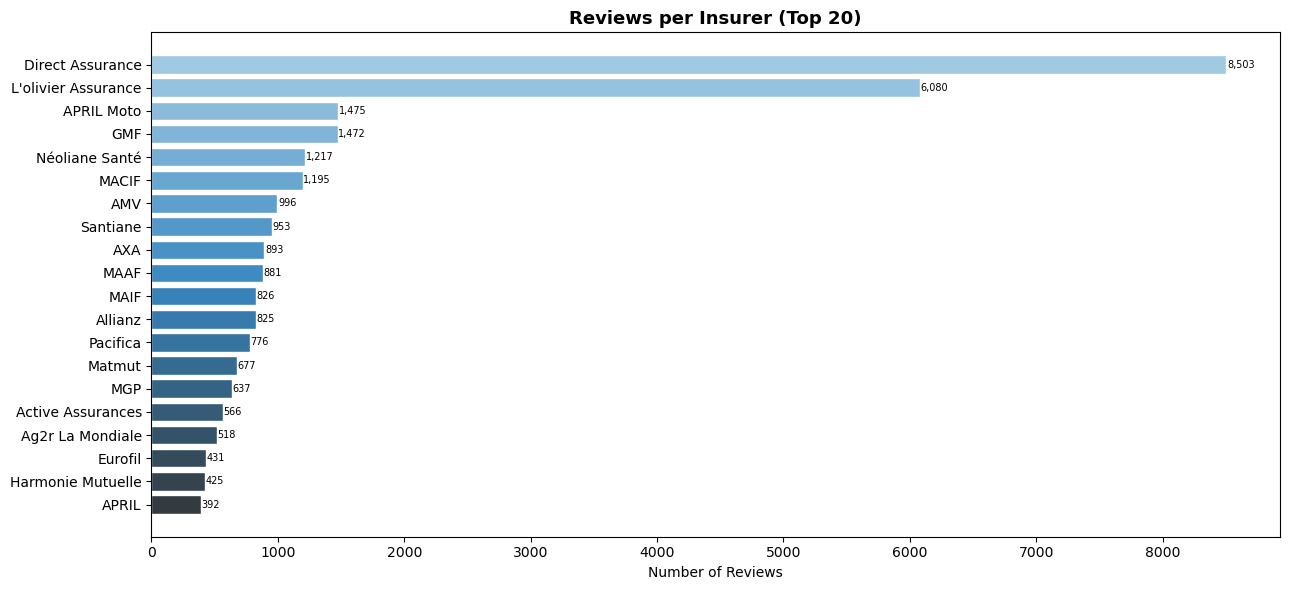

In [16]:
insurer_counts = df["assureur"].value_counts().head(20)

fig, ax = plt.subplots(figsize=(13, 6))
colors = sns.color_palette("Blues_d", len(insurer_counts))
bars = ax.barh(insurer_counts.index, insurer_counts.values,
               color=colors, edgecolor="white")
ax.set_xlabel("Number of Reviews")
ax.set_title("Reviews per Insurer (Top 20)", fontweight="bold", fontsize=13)
ax.invert_yaxis()
for bar in bars:
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():,.0f}", va="center", fontsize=7)
plt.tight_layout()
plt.savefig("visualizations/reviews_per_insurer.png", bbox_inches="tight")
plt.show()

### 3.3 Reviews per Product Type

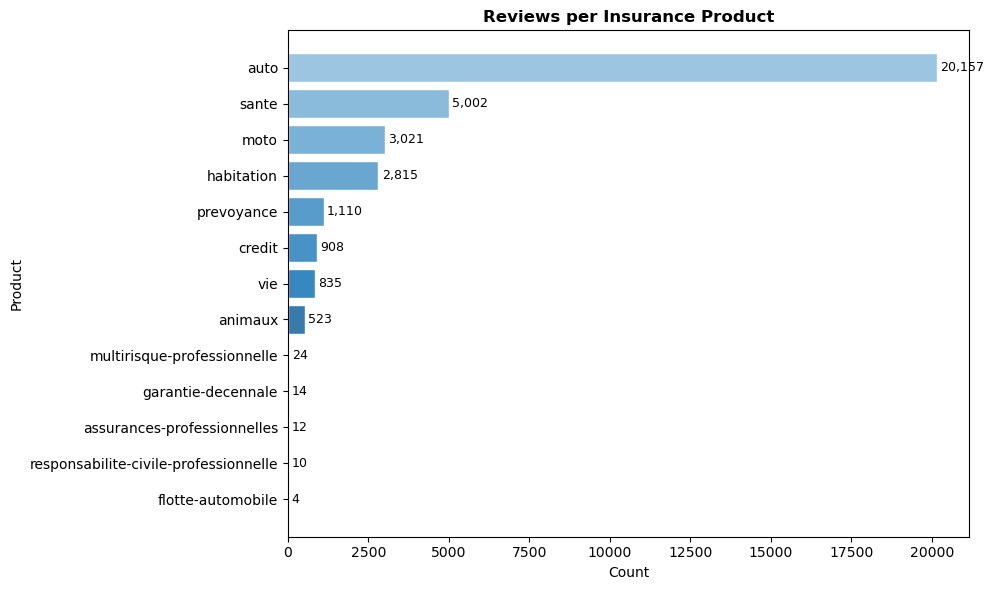

In [30]:
prod_counts = df["produit"].value_counts()

fig, ax = plt.subplots(figsize=(10, 6)) 

bars = ax.barh(prod_counts.index, prod_counts.values,
               color=sns.color_palette("Blues_d", len(prod_counts)),
               edgecolor="white")

ax.set_ylabel("Product")
ax.set_xlabel("Count")
ax.set_title("Reviews per Insurance Product", fontweight="bold")

ax.invert_yaxis()

for bar in bars:
    width = bar.get_width()
    ax.text(width + 100, 
            bar.get_y() + bar.get_height()/2, 
            f"{width:,.0f}", 
            va='center', fontsize=9)

plt.tight_layout()
plt.savefig("visualizations/reviews_per_product_clean.png", bbox_inches="tight")
plt.show()

### 3.4 Average Rating per Insurer (top 20)

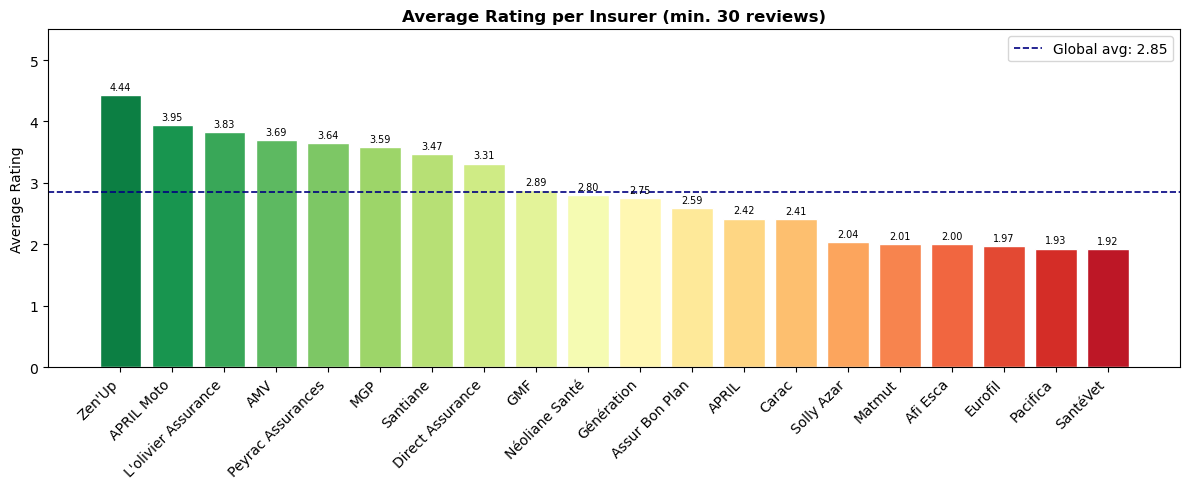

In [34]:
# Only insurers with at least 30 reviews for reliability
insurer_stats = (
    df.groupby("assureur")
    .agg(avg_note=("note", "mean"), count=("note", "size"))
    .query("count >= 30")
    .sort_values("avg_note", ascending=False)
    .head(20)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(12, 5))
palette = sns.color_palette("RdYlGn", len(insurer_stats))
bar_colors = [palette[i] for i in (insurer_stats["avg_note"].rank(method="first").astype(int)-1)]
bars = ax.bar(insurer_stats["assureur"], insurer_stats["avg_note"],
              color=bar_colors, edgecolor="white")
ax.axhline(df["note"].mean(), color="navy", linestyle="--", linewidth=1.2, label=f"Global avg: {df['note'].mean():.2f}")
ax.set_ylabel("Average Rating"); ax.set_ylim(0, 5.5)
ax.set_title("Average Rating per Insurer (min. 30 reviews)", fontweight="bold")
ax.tick_params(axis="x", rotation=45)
ax.legend()
for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.05, f"{bar.get_height():.2f}",
            ha="center", va="bottom", fontsize=7)
plt.tight_layout()
plt.xticks(ha='right')
plt.savefig("visualizations/avg_rating_insurer.png", bbox_inches="tight")
plt.show()

## 4. Frequent Words & N-grams

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def plot_frequent_words(text_list, top_n=20, title="Top Frequent Words"):
    """
    Calcule la fréquence des mots et affiche un graphique à barres.
    text_list: liste de chaînes de caractères (ex: df['clean_text'])
    """
    # 1. Joindre tous les textes et séparer les mots
    all_words = " ".join(text_list).split()
    
    # 2. Compter les fréquences
    word_counts = Counter(all_words)
    common_words = word_counts.most_common(top_n)
    
    # 3. Créer un DataFrame pour faciliter le traçage
    words_df = pd.DataFrame(common_words, columns=['word', 'count'])
    
    # 4. Création du schéma
    plt.figure(figsize=(10, 8))
    ax = sns.barplot(x='count', y='word', data=words_df, palette='viridis')
    
    # Personnalisation
    plt.title(title, fontweight='bold', fontsize=14)
    plt.xlabel('Fréquence', fontsize=12)
    plt.ylabel('Mots', fontsize=12)
    
    # Ajouter les chiffres au bout des barres
    for i in ax.containers:
        ax.bar_label(i, padding=5)
        
    plt.tight_layout()
    plt.show()


## 5. Data Cleaning

In [ ]:
def spelling_correction(text: str, lang: str) -> str:
    text = str(text).lower()
    text = re.sub(r'[^\w\s]', ' ', text)
    if (lang=="fr"):
        model_correct, stop_words = MODEL_CORRECTION_FR, STOP_WORDS_FR
    elif (lang=="en"):
        model_correct, stop_words = MODEL_CORRECTION_EN, STOP_WORDS_EN
    else:
        return text

    words = text.split()
    misspelled = model_correct.unknown(words)
    
    corrected_words = [model_correct.correction(word) or word if word in misspelled else word for word in words]
    clean_words = [word for word in corrected_words if word not in stop_words]
    
    clean_text = " ".join(clean_words)
    return clean_text

### Data Cleaning

### Visualization

### Conclusion

My conclusion

# Next